# Recurrent order-book autoencoder
Each input is a window of consecutive, normalized LOBSTER feature rows (one row per event). The embedder carries its latent state through the window; the decoder reconstructs only the **most recent** book. We fit in feature space and convert predictions back to order-book units for inspection.

## Load chronological feature windows
`LOBSTERLevel10Dataset` computes normalization statistics on the training portion and keeps training and validation chronological. The wrapper below slices its `(events, 40)` feature tensor on demand: item `i` contains events `i` through `i + WINDOW_LENGTH - 1`. Windows are constructed separately for each split, so none straddles the boundary. The training loader shuffles **windows**, never the event order within a window.

In [1]:
from pathlib import Path
import sys

project_dir = Path.cwd() if (Path.cwd() / 'dataset.py').exists() else Path.cwd().parent
sys.path.insert(0, str(project_dir))

import torch
torch.manual_seed(0)

from modules import Embedder, Decoder
from dataset import LOBSTERLevel10Dataset
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from itertools import chain
import pandas as pd

WINDOW_LENGTH = 16  # Number of consecutive order-book events per input.
BATCH_SIZE = 512
EPOCHS = 15

class FeatureWindows(Dataset):
    def __init__(self, data: LOBSTERLevel10Dataset, length: int):
        if not 1 <= length <= len(data):
            raise ValueError('Window length must be between 1 and the split size')
        self.data = data
        self.length = length

    def __len__(self):
        return len(self.data) - self.length + 1

    def __getitem__(self, index):
        return self.data.features[index:index + self.length]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

embedder = Embedder().to(device)
decoder = Decoder.to(device)

train_data = LOBSTERLevel10Dataset(train=True, normalize=True)
validation_data = LOBSTERLevel10Dataset(train=False, normalize=True)
train_windows = FeatureWindows(train_data, WINDOW_LENGTH)
validation_windows = FeatureWindows(validation_data, WINDOW_LENGTH)
train_loader = DataLoader(train_windows, shuffle=True, batch_size=BATCH_SIZE)

optimizer = optim.Adam(chain(embedder.parameters(), decoder.parameters()), lr=3e-4)
loss = nn.MSELoss()

In [2]:
# A window is (events, features); the final event is its reconstruction target.
sample = next(iter(DataLoader(train_windows, batch_size=2, shuffle=False)))
assert sample.shape == (2, WINDOW_LENGTH, train_data.FEATURE_DIMS)
torch.testing.assert_close(sample[0, -1], train_data.features[WINDOW_LENGTH - 1])
torch.testing.assert_close(sample[1, 0], sample[0, 1])
torch.testing.assert_close(validation_windows[0][0], validation_data.features[0])
torch.testing.assert_close(validation_windows[len(validation_windows) - 1][-1], validation_data.features[-1])
print(f'Train/validation windows: {len(train_windows):,} / {len(validation_windows):,}')
print(f'Batch shape: {sample.shape}; first target event index: {WINDOW_LENGTH - 1}')
display(pd.DataFrame(sample[0].numpy(), columns=train_data.FEATURE_NAMES).iloc[[0, -1]])
display(train_data.books.iloc[[WINDOW_LENGTH - 1]])

Train/validation windows: 229,271 / 40,447
Batch shape: torch.Size([2, 16, 40]); first target event index: 15


,log_midpoint,log1p_spread,log1p_ask_gap_2,log1p_ask_gap_3,log1p_ask_gap_4,log1p_ask_gap_5,log1p_ask_gap_6,log1p_ask_gap_7,log1p_ask_gap_8,log1p_ask_gap_9,...,log1p_bid_size_1,log1p_bid_size_2,log1p_bid_size_3,log1p_bid_size_4,log1p_bid_size_5,log1p_bid_size_6,log1p_bid_size_7,log1p_bid_size_8,log1p_bid_size_9,log1p_bid_size_10
0,0.418305,4.156386,1.182037,-0.632391,6.355902,5.057428,4.967793,7.247836,11.544568,12.327069,...,0.003851,0.941385,0.417750,-1.576596,0.116648,3.397315,-0.248531,3.866338,-0.424605,-0.457329
15,0.664463,0.241519,-0.707711,1.137516,-0.647654,6.386892,5.148420,4.844782,7.075727,11.406751,...,-1.190311,0.400004,-2.419242,-1.262273,0.116648,-0.733764,-0.248531,0.376358,-0.424605,-3.041145


,ASKp1,ASKs1,BIDp1,BIDs1,ASKp2,ASKs2,BIDp2,BIDs2,ASKp3,ASKs3,...,BIDp8,BIDs8,ASKp9,ASKs9,BIDp9,BIDs9,ASKp10,ASKs10,BIDp10,BIDs10
15,2239500,100,2238100,21,2239600,20,2237500,100,2239900,100,...,2230700,200,2267700,100,2230400,100,2294300,100,2230000,10


## Train the recurrent reconstruction
The hidden state starts empty for each batch of windows. For each event, `Embedder` combines its features with the preceding state; only the final state reaches the decoder. MSE compares the decoded normalized features with the **last** row of each window.

In [3]:
def reconstruct_last(windows):
    hidden = None
    for step in range(windows.shape[1]):
        hidden = embedder(windows[:, step], hidden)
    return decoder(hidden)

embedder.train()
decoder.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for windows in train_loader:
        windows = windows.to(device)
        optimizer.zero_grad()
        recon = reconstruct_last(windows)
        recon_loss = loss(recon, windows[:, -1])
        recon_loss.backward()
        # Limit occasional large gradients from backpropagation through the window.
        nn.utils.clip_grad_norm_(chain(embedder.parameters(), decoder.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += recon_loss.item() * len(windows)
    print(f'Epoch {epoch + 1}: training feature MSE = {total_loss / len(train_windows):.7f}')

Epoch 1: training feature MSE = 0.4985087
Epoch 2: training feature MSE = 0.1791424
Epoch 3: training feature MSE = 0.0663401
Epoch 4: training feature MSE = 0.0222843
Epoch 5: training feature MSE = 0.0137247
Epoch 6: training feature MSE = 0.0093814
Epoch 7: training feature MSE = 0.0060866
Epoch 8: training feature MSE = 0.0063170
Epoch 9: training feature MSE = 0.0055419
Epoch 10: training feature MSE = 0.0048999
Epoch 11: training feature MSE = 0.0024851
Epoch 12: training feature MSE = 0.0024309
Epoch 13: training feature MSE = 0.0028045
Epoch 14: training feature MSE = 0.0024090
Epoch 15: training feature MSE = 0.0029058


## Inspect reconstructions on both splits
Prediction order follows window start order, so prediction `i` corresponds to book event `i + WINDOW_LENGTH - 1` in its split. Metrics use every eligible target; plots show a shorter interval. Book-level errors are computed after reversing normalization and rounding to valid tick prices and integer sizes.

Training feature MSE: 0.0025245
Validation feature MSE: 0.0021651
Training midpoint MAE: $0.09784
Training spread MAE: $0.00116
Training size MAE: 6.58 shares
Validation midpoint MAE: $0.09055
Validation spread MAE: $0.00016
Validation size MAE: 7.42 shares


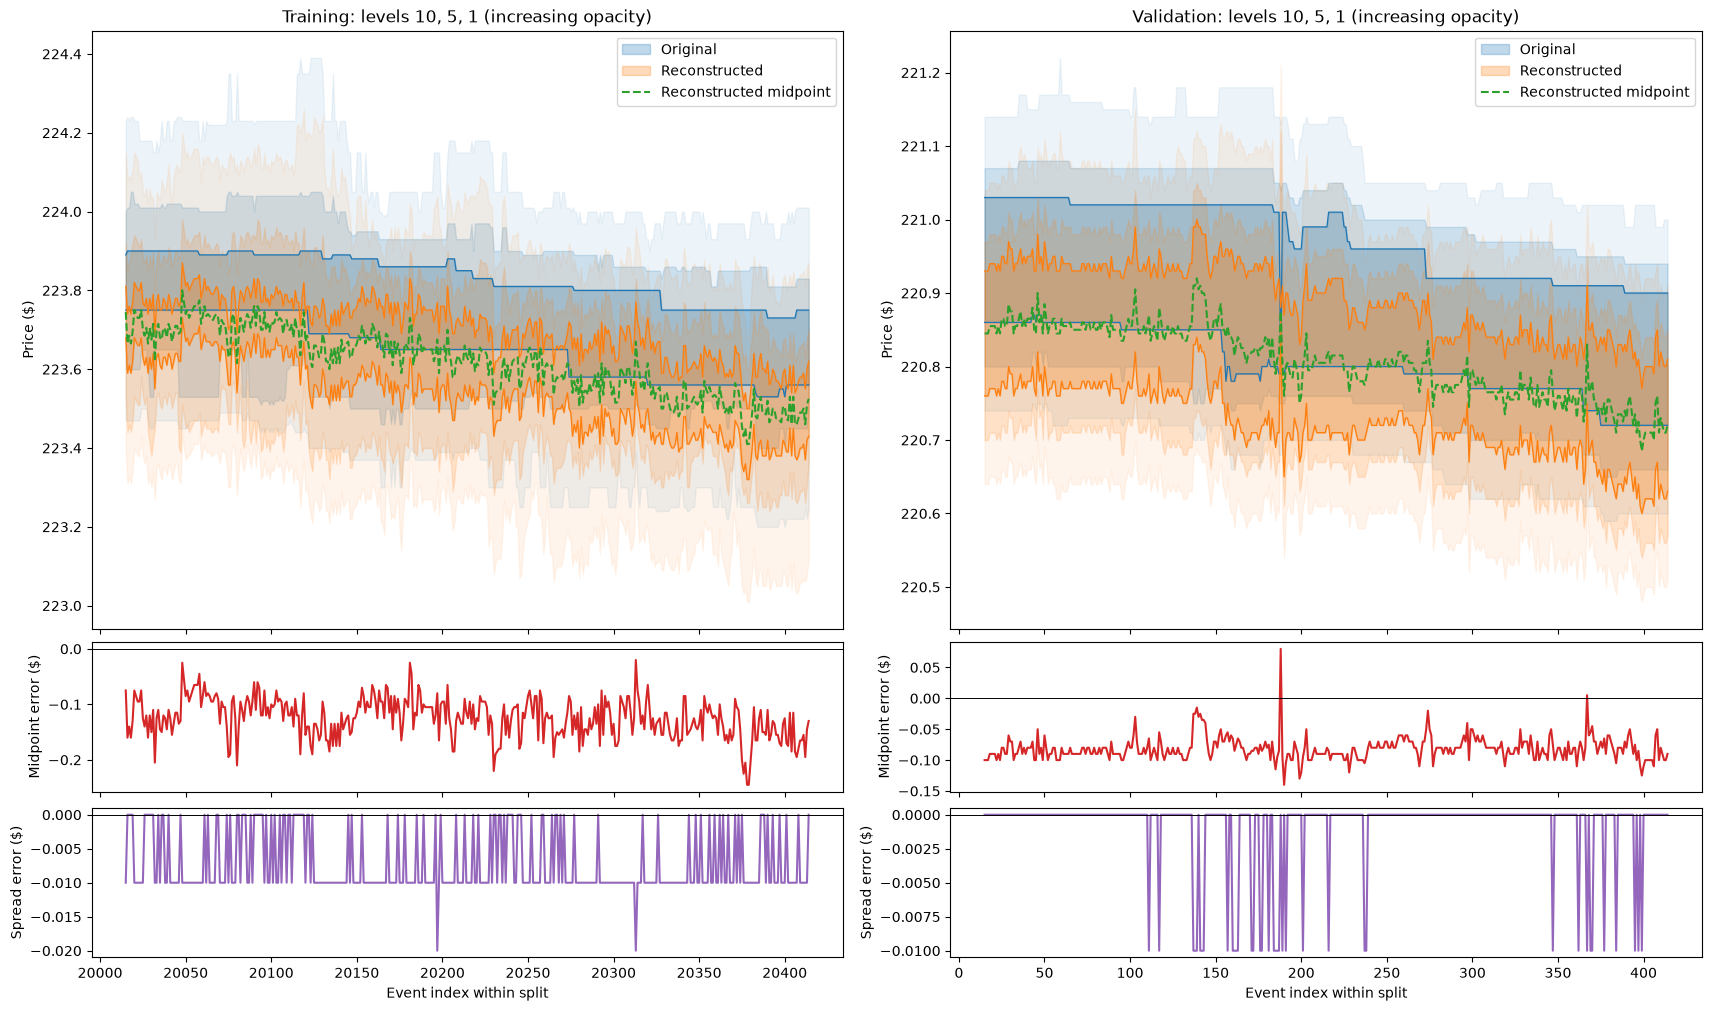

,ASKp1,ASKs1,BIDp1,BIDs1,ASKp2,ASKs2,BIDp2,BIDs2,ASKp3,ASKs3,...,BIDp8,BIDs8,ASKp9,ASKs9,BIDp9,BIDs9,ASKp10,ASKs10,BIDp10,BIDs10
0,2209300,226,2207600,128,2209400,125,2207500,22,2209500,24,...,2206600,104,2210300,196,2206500,190,2210400,699,2206400,255
1,2209300,226,2207600,128,2209400,126,2207500,22,2209500,25,...,2206600,104,2210300,196,2206500,190,2210400,699,2206400,349
2,2209300,226,2207600,128,2209400,125,2207500,22,2209500,25,...,2206600,104,2210300,195,2206500,191,2210400,701,2206400,255
3,2209400,226,2207700,128,2209500,125,2207600,22,2209600,24,...,2206700,104,2210400,195,2206600,190,2210500,701,2206500,160
4,2209400,225,2207700,128,2209500,125,2207600,22,2209600,24,...,2206700,104,2210400,196,2206600,190,2210500,800,2206500,160


In [4]:
import matplotlib.pyplot as plt
import numpy as np

embedder.eval()
decoder.eval()
results = {}
with torch.no_grad():
    for split, windows_data in (('Training', train_windows), ('Validation', validation_windows)):
        predictions = torch.cat([
            reconstruct_last(batch.to(device)).cpu()
            for batch in DataLoader(windows_data, shuffle=False, batch_size=BATCH_SIZE)
        ])
        data = windows_data.data
        targets = data.features[WINDOW_LENGTH - 1:]
        print(f'{split} feature MSE: {loss(predictions, targets).item():.7f}')
        results[split] = (data.books.iloc[WINDOW_LENGTH - 1:].reset_index(drop=True),
                          data.feature_sequence_to_df(predictions))

# Metrics use each complete split; plots use short windows for legibility.
fig, axes = plt.subplots(
    3, 2, figsize=(17, 10), sharex='col', layout='constrained',
    gridspec_kw={'height_ratios': [4, 1, 1]},
)
plot_length = 400
for column, (split, (books, reconstructed_books)) in enumerate(results.items()):
    midpoints = (books['ASKp1'] + books['BIDp1']) / 2
    midpoints_recon = (reconstructed_books['ASKp1'] + reconstructed_books['BIDp1']) / 2
    spreads = books['ASKp1'] - books['BIDp1']
    spreads_recon = reconstructed_books['ASKp1'] - reconstructed_books['BIDp1']
    size_columns = [name for name in books.columns if 's' in name]
    print(f'{split} midpoint MAE: ${np.abs(midpoints_recon - midpoints).mean() / 10_000:.5f}')
    print(f'{split} spread MAE: ${np.abs(spreads_recon - spreads).mean() / 10_000:.5f}')
    print(f'{split} size MAE: {(books[size_columns] - reconstructed_books[size_columns]).abs().to_numpy().mean():.2f} shares')

    plot_start = 20_000 if split == 'Training' else 0
    window = slice(plot_start, plot_start + plot_length)
    x = np.arange(WINDOW_LENGTH - 1, WINDOW_LENGTH - 1 + len(books))[window]
    ax_book, ax_mid, ax_spread = axes[:, column]
    for book, label, color in ((books, 'Original', 'tab:blue'),
                               (reconstructed_books, 'Reconstructed', 'tab:orange')):
        for level, alpha in ((10, 0.08), (5, 0.16), (1, 0.28)):
            ax_book.fill_between(
                x, book[f'BIDp{level}'].iloc[window] / 10_000,
                book[f'ASKp{level}'].iloc[window] / 10_000,
                color=color, alpha=alpha, label=label if level == 1 else None,
            )
        for side in ('BID', 'ASK'):
            ax_book.plot(x, book[f'{side}p1'].iloc[window] / 10_000,
                         color=color, linewidth=0.9)
    ax_book.plot(x, midpoints_recon.iloc[window] / 10_000,
                 color='tab:green', linestyle='--', linewidth=1.5,
                 label='Reconstructed midpoint')
    ax_book.set(title=f'{split}: levels 10, 5, 1 (increasing opacity)', ylabel='Price ($)')
    ax_book.legend()
    ax_mid.plot(x, (midpoints_recon - midpoints).iloc[window] / 10_000, color='tab:red')
    ax_mid.axhline(0, color='black', linewidth=0.7)
    ax_mid.set(ylabel='Midpoint error ($)')
    ax_spread.plot(x, (spreads_recon - spreads).iloc[window] / 10_000, color='tab:purple')
    ax_spread.axhline(0, color='black', linewidth=0.7)
    ax_spread.set(xlabel='Event index within split', ylabel='Spread error ($)')
plt.show()
results['Validation'][1].head()